In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os
from pathlib import Path
import random
from matplotlib.patches import Polygon

In [2]:
def clean_dataset(file_path):
    """
    Clean the dataset by parsing arrays and handling data types
    """
    print("Loading and cleaning dataset...")
    
    # Read the CSV file
    df = pd.read_csv(file_path)
    
    # Parse string arrays to actual lists
    def parse_array(arr_str):
        try:
            return ast.literal_eval(arr_str)
        except:
            return []
    
    # Apply parsing to current columns
    df['A_Current_Parsed'] = df['A Current'].apply(parse_array)
    df['B_Current_Parsed'] = df['B Current'].apply(parse_array)
    df['A_Voltage_Parsed'] = df['A Voltage'].apply(parse_array)
    df['B_Voltage_Parsed'] = df['B Voltage'].apply(parse_array)
    
    # Remove rows with empty arrays
    df = df[df['A_Current_Parsed'].apply(len) > 0]
    df = df[df['B_Current_Parsed'].apply(len) > 0]
    
    # Reset index
    df = df.reset_index(drop=True)
    
    print(f"Dataset cleaned. Total records: {len(df)}")
    print(f"Unique Point Machines: {df['Point Machine Name'].nunique()}")
    print(f"Point Machine Names: {df['Point Machine Name'].unique().tolist()}")
    
    return df


In [3]:
def create_signal_image(signal_data, output_path, image_size=(224, 224), dpi=100):
    """
    Create a clean signal image with filled area under curve
    """
    if len(signal_data) == 0:
        return False
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(image_size[0]/dpi, image_size[1]/dpi), dpi=dpi)
    
    # Remove all axes, labels, ticks, etc.
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Set background to white
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Create x-axis data
    x = np.arange(len(signal_data))
    y = np.array(signal_data)
    
    # Normalize y-axis to use full image height
    if len(y) > 0 and np.max(y) != np.min(y):
        y_normalized = (y - np.min(y)) / (np.max(y) - np.min(y))
    else:
        y_normalized = y
    
    # Plot the line
    ax.plot(x, y_normalized, color='blue', linewidth=2)
    
    # Fill area under the curve
    ax.fill_between(x, y_normalized, alpha=0.7, color='lightblue')
    
    # Set axis limits to use full image space
    ax.set_xlim(0, len(signal_data)-1)
    ax.set_ylim(0, 1)
    
    # Remove margins
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Save the image
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0, 
                facecolor='white', edgecolor='none', dpi=dpi)
    plt.close()
    
    return True

In [4]:
def generate_dataset_images(df, output_dir, images_per_machine=100):
    """
    Generate dataset images for each point machine
    """
    print("Generating dataset images...")
    
    # Create output directory
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Group by Point Machine Name
    grouped = df.groupby('Point Machine Name')
    
    total_images_created = 0
    
    for machine_name, group in grouped:
        print(f"Processing {machine_name}...")
        
        # Create folder for this machine
        machine_folder = Path(output_dir) / machine_name.replace('/', '_').replace('\\', '_')
        machine_folder.mkdir(parents=True, exist_ok=True)
        
        # Get all A Current signals for this machine
        signals = group['A_Current_Parsed'].tolist()
        
        # If we have fewer signals than requested, duplicate some randomly
        if len(signals) < images_per_machine:
            # Repeat signals to reach desired count
            multiplier = (images_per_machine // len(signals)) + 1
            extended_signals = signals * multiplier
            signals = extended_signals[:images_per_machine]
        else:
            # Randomly sample if we have more signals than needed
            signals = random.sample(signals, images_per_machine)
        
        # Generate images
        images_created = 0
        for i, signal in enumerate(signals):
            if len(signal) > 0:  # Only process non-empty signals
                image_path = machine_folder / f"signal_{i:03d}.png"
                
                if create_signal_image(signal, image_path):
                    images_created += 1
                    
                if images_created >= images_per_machine:
                    break
        
        print(f"Created {images_created} images for {machine_name}")
        total_images_created += images_created
    
    print(f"Total images created: {total_images_created}")
    return total_images_created


In [5]:
def visualize_sample_signals(df, num_samples=5):
    """
    Create a sample visualization of A Current and B Current signals
    """
    print("Creating sample signal visualizations...")
    
    # Sample random records
    sample_df = df.sample(n=min(num_samples, len(df)))
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 3*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        # A Current
        axes[i, 0].plot(row['A_Current_Parsed'], color='blue', linewidth=2)
        axes[i, 0].fill_between(range(len(row['A_Current_Parsed'])), 
                               row['A_Current_Parsed'], alpha=0.3, color='lightblue')
        axes[i, 0].set_title(f"{row['Point Machine Name']} - A Current\n{row['Time']} - {row['Direction']}")
        axes[i, 0].grid(True, alpha=0.3)
        
        # B Current
        axes[i, 1].plot(row['B_Current_Parsed'], color='red', linewidth=2)
        axes[i, 1].fill_between(range(len(row['B_Current_Parsed'])), 
                               row['B_Current_Parsed'], alpha=0.3, color='lightcoral')
        axes[i, 1].set_title(f"{row['Point Machine Name']} - B Current\n{row['Time']} - {row['Direction']}")
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('sample_signals_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Sample visualization saved as 'sample_signals_visualization.png'")


Loading and cleaning dataset...
Dataset cleaned. Total records: 17790
Unique Point Machines: 9
Point Machine Names: ['PT71', 'PT74', 'PT76', 'PT77', 'PT57', 'PT54', 'PT41', 'PT103', 'PT154']
Creating sample signal visualizations...


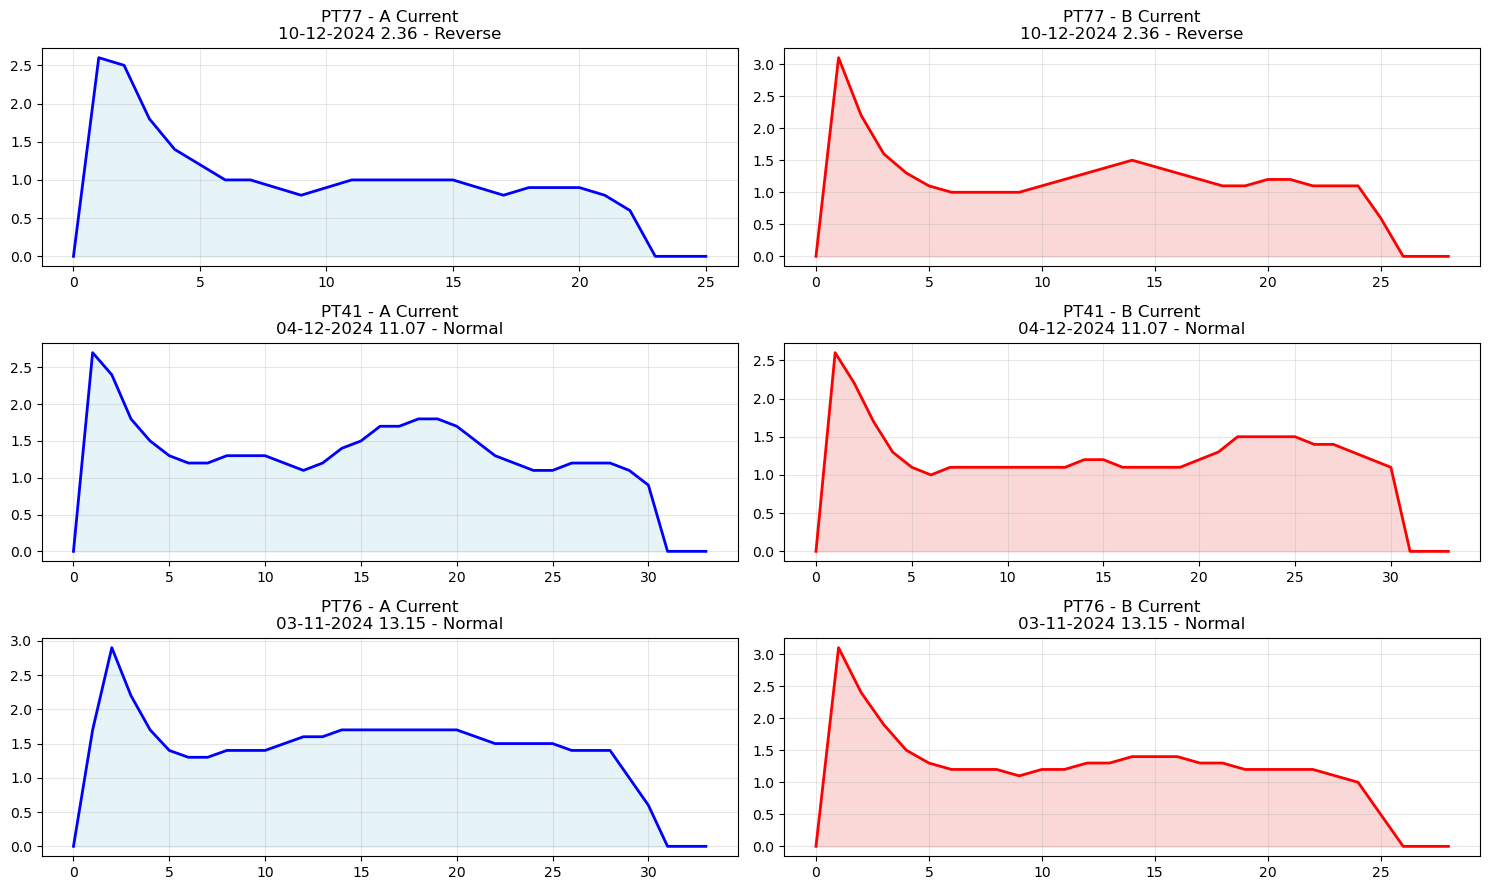

Sample visualization saved as 'sample_signals_visualization.png'
Generating dataset images...
Processing PT103...
Created 100 images for PT103
Processing PT154...
Created 100 images for PT154
Processing PT41...
Created 100 images for PT41
Processing PT54...
Created 100 images for PT54
Processing PT57...
Created 100 images for PT57
Processing PT71...
Created 100 images for PT71
Processing PT74...
Created 100 images for PT74
Processing PT76...
Created 100 images for PT76
Processing PT77...
Created 100 images for PT77
Total images created: 900

PROCESSING COMPLETE!
Dataset records processed: 17790
Unique point machines: 9
Total images generated: 900
Images saved in: signal_dataset_images
Images per machine: 100


In [6]:
def main():
    """
    Main function to process the dataset and generate images
    """
    # Configuration
    INPUT_FILE = '/Users/anamikasaroha/Energy7_Week1/week_6/SECR2_TWS.csv'  # Replace with your actual file path
    OUTPUT_DIR = 'signal_dataset_images'
    IMAGES_PER_MACHINE = 100
    
    try:
        # Step 1: Clean the dataset
        df = clean_dataset(INPUT_FILE)
        
        # Step 2: Create sample visualization
        visualize_sample_signals(df, num_samples=3)
        
        # Step 3: Generate dataset images
        total_images = generate_dataset_images(df, OUTPUT_DIR, IMAGES_PER_MACHINE)
        
        # Step 4: Print summary
        print("\n" + "="*50)
        print("PROCESSING COMPLETE!")
        print("="*50)
        print(f"Dataset records processed: {len(df)}")
        print(f"Unique point machines: {df['Point Machine Name'].nunique()}")
        print(f"Total images generated: {total_images}")
        print(f"Images saved in: {OUTPUT_DIR}")
        print(f"Images per machine: {IMAGES_PER_MACHINE}")
       
        
    except FileNotFoundError:
        print(f"Error: File '{INPUT_FILE}' not found. Please check the file path.")
    except Exception as e:
        print(f"Error occurred: {str(e)}")

if __name__ == "__main__":
    main()

In [10]:
def create_signalimage(signal_data, output_path, image_size=(400, 150), dpi=100):
    """
    Create a clean signal image with filled area under curve
    """
    if len(signal_data) == 0:
        return False
    
    # Filter out very small signals (threshold)
    if len(signal_data) < 5:
        return False
    
    # Create figure and axis with rectangular dimensions
    fig, ax = plt.subplots(figsize=(image_size[0]/dpi, image_size[1]/dpi), dpi=dpi)
    
    # Remove all axes, labels, ticks, etc.
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Set background to white
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Create x-axis data
    x = np.arange(len(signal_data))
    y = np.array(signal_data)
    
    # Apply signal quality thresholds
    max_val = np.max(y)
    min_val = np.min(y)
    signal_range = max_val - min_val
    
    # Skip signals with very small range (likely noise or flat signals)
    if signal_range < 0.1:
        plt.close()
        return False
    
    # Normalize y-axis to use full image height with some padding
    y_normalized = (y - min_val) / signal_range
    
    # Add small padding at top and bottom for better visualization
    y_padded = y_normalized * 0.9 + 0.05
    
    # Plot the line with better visibility
    ax.plot(x, y_padded, color='#2E86AB', linewidth=2.5, antialiased=True)
    
    # Fill area under the curve with gradient-like effect
    ax.fill_between(x, 0, y_padded, alpha=0.6, color='#A8DADC')
    
    # Set axis limits to use full image space
    ax.set_xlim(0, len(signal_data)-1)
    ax.set_ylim(0, 1)
    
    # Remove margins
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    
    # Save the image
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0, 
                facecolor='white', edgecolor='none', dpi=dpi)
    plt.close()
    
    return True


In [11]:
def generate_datasetimages(df, output_dir, images_per_machine=100):
    """
    Generate dataset images for each point machine with quality filtering
    """
    print("Generating dataset images...")
    
    # Create output directory
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Group by Point Machine Name
    grouped = df.groupby('Point Machine Name')
    
    total_images_created = 0
    
    for machine_name, group in grouped:
        print(f"Processing {machine_name}...")
        
        # Create folder for this machine
        machine_folder = Path(output_dir) / machine_name.replace('/', '_').replace('\\', '_')
        machine_folder.mkdir(parents=True, exist_ok=True)
        
        # Get all A Current signals for this machine
        all_signals = group['A_Current_Parsed'].tolist()
        
        # Filter signals based on quality thresholds
        quality_signals = []
        for signal in all_signals:
            if len(signal) >= 10:  # Minimum length threshold
                signal_array = np.array(signal)
                max_val = np.max(signal_array)
                min_val = np.min(signal_array)
                signal_range = max_val - min_val
                
                # Only keep signals with meaningful variation
                if signal_range >= 0.5 and max_val > 0.1:
                    quality_signals.append(signal)
        
        print(f"  Found {len(quality_signals)} quality signals out of {len(all_signals)} total")
        
        # If we have fewer quality signals than requested, duplicate some randomly
        if len(quality_signals) < images_per_machine:
            if len(quality_signals) > 0:
                # Repeat signals to reach desired count
                multiplier = (images_per_machine // len(quality_signals)) + 1
                extended_signals = quality_signals * multiplier
                signals = extended_signals[:images_per_machine]
            else:
                print(f"  Warning: No quality signals found for {machine_name}")
                continue
        else:
            # Randomly sample if we have more signals than needed
            signals = random.sample(quality_signals, images_per_machine)
        
        # Generate images
        images_created = 0
        for i, signal in enumerate(signals):
            image_path = machine_folder / f"signal_{i:03d}.png"
            
            if create_signalimage(signal, image_path, image_size=(400, 150)):
                images_created += 1
                
            if images_created >= images_per_machine:
                break
        
        print(f"  Created {images_created} images for {machine_name}")
        total_images_created += images_created
    
    print(f"Total images created: {total_images_created}")
    return total_images_created


In [12]:
def visualize_samplesignals(df, num_samples=5):
    """
    Create a sample visualization of A Current and B Current signals
    """
    print("Creating sample signal visualizations...")
    
    # Sample random records
    sample_df = df.sample(n=min(num_samples, len(df)))
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(15, 3*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        # A Current
        axes[i, 0].plot(row['A_Current_Parsed'], color='blue', linewidth=2)
        axes[i, 0].fill_between(range(len(row['A_Current_Parsed'])), 
                               row['A_Current_Parsed'], alpha=0.3, color='lightblue')
        axes[i, 0].set_title(f"{row['Point Machine Name']} - A Current\n{row['Time']} - {row['Direction']}")
        axes[i, 0].grid(True, alpha=0.3)
        
        # B Current
        axes[i, 1].plot(row['B_Current_Parsed'], color='red', linewidth=2)
        axes[i, 1].fill_between(range(len(row['B_Current_Parsed'])), 
                               row['B_Current_Parsed'], alpha=0.3, color='lightcoral')
        axes[i, 1].set_title(f"{row['Point Machine Name']} - B Current\n{row['Time']} - {row['Direction']}")
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('sample_signals_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Sample visualization saved as 'sample_signals_visualization.png'")


Loading and cleaning dataset...
Dataset cleaned. Total records: 17790
Unique Point Machines: 9
Point Machine Names: ['PT71', 'PT74', 'PT76', 'PT77', 'PT57', 'PT54', 'PT41', 'PT103', 'PT154']
Creating sample signal visualizations...


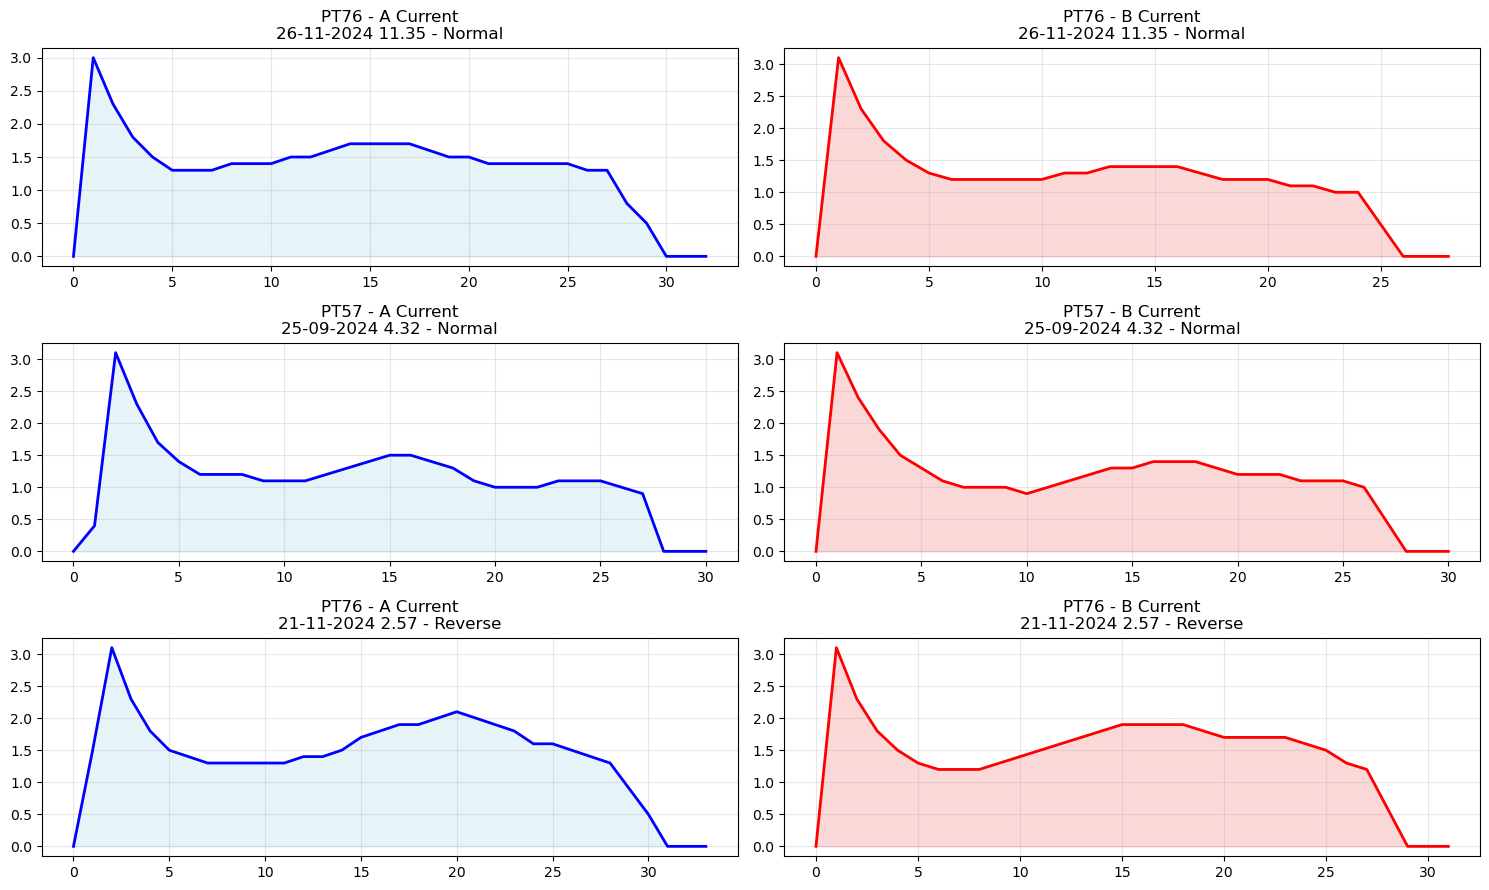

Sample visualization saved as 'sample_signals_visualization.png'
Generating dataset images...
Processing PT103...
  Found 345 quality signals out of 346 total
  Created 100 images for PT103
Processing PT154...
  Found 5318 quality signals out of 5332 total
  Created 100 images for PT154
Processing PT41...
  Found 313 quality signals out of 313 total
  Created 100 images for PT41
Processing PT54...
  Found 856 quality signals out of 856 total
  Created 100 images for PT54
Processing PT57...
  Found 1912 quality signals out of 1912 total
  Created 100 images for PT57
Processing PT71...
  Found 995 quality signals out of 996 total
  Created 100 images for PT71
Processing PT74...
  Found 422 quality signals out of 422 total
  Created 100 images for PT74
Processing PT76...
  Found 2524 quality signals out of 2525 total
  Created 100 images for PT76
Processing PT77...
  Found 5084 quality signals out of 5088 total
  Created 100 images for PT77
Total images created: 900

PROCESSING COMPLETE!


In [13]:
def main():
    """
    Main function to process the dataset and generate images
    """
    # Configuration
    INPUT_FILE = '/Users/anamikasaroha/Energy7_Week1/week_6/SECR2_TWS.csv'  # Replace with your actual file path
    OUTPUT_DIR = 'signal_dataset_images_v2'
    IMAGES_PER_MACHINE = 100
    
    try:
        # Step 1: Clean the dataset
        df = clean_dataset(INPUT_FILE)
        
        # Step 2: Create sample visualization
        visualize_samplesignals(df, num_samples=3)
        
        # Step 3: Generate dataset images
        total_images = generate_datasetimages(df, OUTPUT_DIR, IMAGES_PER_MACHINE)
        
        # Step 4: Print summary
        print("\n" + "="*50)
        print("PROCESSING COMPLETE!")
        print("="*50)
        print(f"Dataset records processed: {len(df)}")
        print(f"Unique point machines: {df['Point Machine Name'].nunique()}")
        print(f"Total images generated: {total_images}")
        print(f"Images saved in: {OUTPUT_DIR}")
        print(f"Images per machine: {IMAGES_PER_MACHINE}")
        
       
        
    except FileNotFoundError:
        print(f"Error: File '{INPUT_FILE}' not found. Please check the file path.")
    except Exception as e:
        print(f"Error occurred: {str(e)}")

if __name__ == "__main__":
    main()